# 0. Introduction
The goal of this ntebook is to quality control AGNSourceLipunova2018.

# 0 Cont. Checking Perturbations



In [3]:
# from lightcurvelynx (pasting to see it all)
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

def sample_damped_random_walk(times, tau_v, sf_inf, t0, rng=None):
    """Sample a damped random walk.

    Parameters
    ----------
    times : np.ndarray
        A length T array with the times at which to sample the damped random
        walk (in MJD).
    tau_v : np.ndarray
        A length W array with timescale of the damped random walk (in s).
    sf_inf : np.ndarray
        A length W array with structure function at infinity time in magnitude.
    t0 : float
        The initial time moment (in MJD).
    rng : np.random.Generator, optional
        The random number generator to use.
        Default: None

    Returns
    -------
    samples : float
        The sampled value of the damped random walk.
    """
    if rng is None:
        rng = np.random.default_rng()

    if len(sf_inf) != len(tau_v):
        raise ValueError(
            "The arrays sf_inf and tau_v must have the same length. "
            f"Received lengths: sf_inf={len(sf_inf)}, tau_v={len(tau_v)}"
        )
    samples = np.zeros((len(times), len(tau_v)))

    # Set the initial values.
    curr_t = t0
    delta_m = rng.random() * sf_inf

    # Iterate over each time step.
    for idx, time in enumerate(times):
        if time <= curr_t and idx != 0:
            raise ValueError("Times must be monotonically increasing.")

        dt = time - curr_t
        delta_m = delta_m * np.exp(-dt / tau_v) + sf_inf * np.sqrt(1 - np.exp(-2 * dt / tau_v)) * rng.random()
        samples[idx, :] = delta_m

    return samples

def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    white_noise = np.random.normal(0, 1, n_samples)
    fft_white = jnp.fft.rfft(white_noise)
    frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor = scaling_factor.at[0].set(0.0)
    fft_colored = fft_white * scaling_factor
    colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
    return jnp.exp(colored_noise - jnp.var(colored_noise)/2)

def generate_perturbations_vector_neg(alpha, n_samples, sample_rate=1.0):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    white_noise = np.random.normal(0, 1, n_samples)
    fft_white = jnp.fft.rfft(white_noise)
    frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor = scaling_factor.at[0].set(0.0)
    fft_colored = fft_white * scaling_factor
    colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
    return colored_noise






[[244.73816495 244.73816495]
 [207.36264901 207.36264901]
 [205.09512865 205.09512865]
 ...
 [204.84997643 204.84997643]
 [205.09512865 205.09512865]
 [207.36264901 207.36264901]]
(2000, 2)


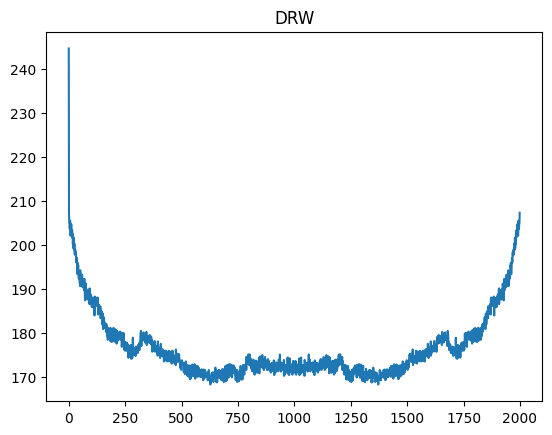

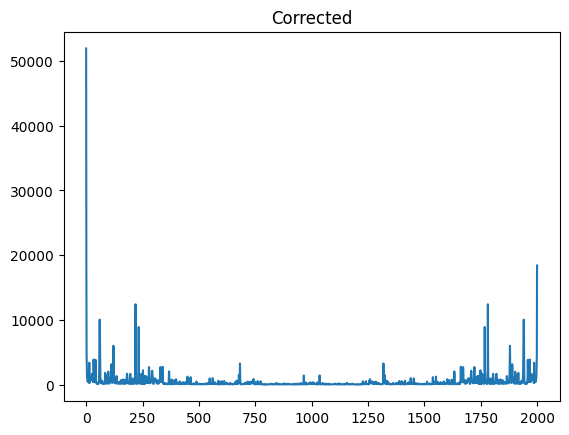

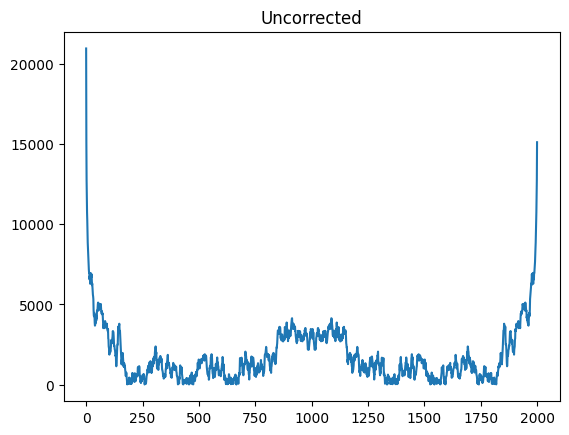

In [4]:
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

times = np.linspace(6300, 6500, 2000)
drw_samples = sample_damped_random_walk(times, np.asarray([24, 24]), np.asarray([0.5, 0.5]), 6300)
cov_func_drw = np.abs(np.fft.irfft(np.abs(np.fft.rfft(drw_samples, axis=0))**2,axis=0))
print(cov_func_drw)
print(np.shape(cov_func_drw))

my_samples = generate_perturbations_vector (alpha=0.9, n_samples = 2000)
cov_func_my = np.abs(np.fft.irfft(np.abs(np.fft.rfft(my_samples))**2))

my_samples_neg = generate_perturbations_vector_neg(alpha=0.9, n_samples = 2000)
cov_func_neg = np.abs(np.fft.irfft(np.abs(np.fft.rfft(my_samples_neg))**2))


plt.plot(cov_func_drw[:, 0])
plt.title("DRW")
plt.show()

plt.plot(cov_func_my)
plt.title("Corrected")
plt.show()


plt.plot(cov_func_neg)
plt.title("Uncorrected")
plt.show()

# 1. Base SED
We will first compare the model's base SED with lightcurvelynx's

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.utils.constants import M_sun, c_nm
from lightcurvelynx.models.agn import AGN
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from cosmographi.utils.flux import f_l
from cosmographi.utils.constants import c_nm, c_cm, c_m, G, h_m2kg, me_g, k, h, k_si

def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    white_noise = np.random.normal(0, 1, n_samples)
    fft_white = jnp.fft.rfft(white_noise)
    frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor = scaling_factor.at[0].set(0.0)
    fft_colored = fft_white * scaling_factor
    colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
    return jnp.exp(colored_noise - jnp.var(colored_noise)/2)

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
perturbations = generate_perturbations_vector (alpha=0.5, n_samples = 1000)
wavelengths = jnp.asarray([360, 475, 620, 755, 870, 985])


[1.85464622e-11 1.72050162e-11 1.59145231e-11 1.49855116e-11
 1.43370215e-11 1.37851968e-11]
Their fluxes per freq: [1.85464622e-11 1.72050162e-11 1.59145231e-11 1.49855116e-11
 1.43370215e-11 1.37851968e-11]
Their fluxes: [42.90192502 22.86064974 12.41169094  7.88130932  5.67859814  4.2595254 ]
My fluxes: [42.88178055 22.85002202 12.40595738  7.87768048  5.67598822  4.25757021]
[0.02014447 0.01062772 0.00573356 0.00362884 0.00260991 0.00195519]


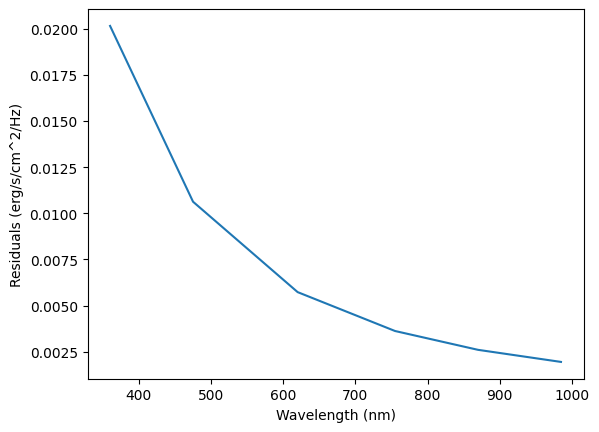

Percentage residuals: [0.0469547  0.04648912 0.04619481 0.04604366 0.0459605  0.04590155]


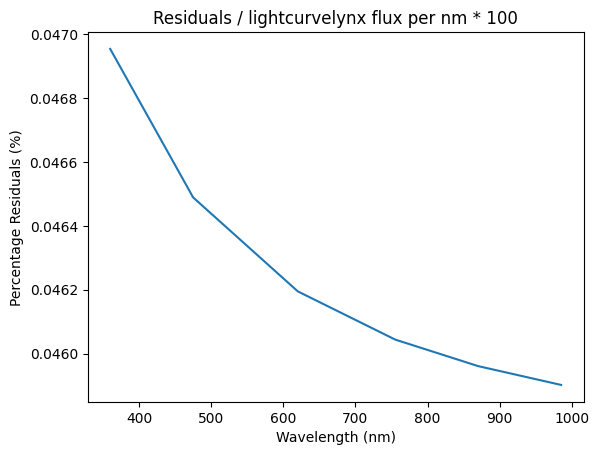

In [7]:
ABSOLUTE_FLUX_TO_LUM_DENSITY = (10 * 3.086e+18) **2 * jnp.pi * 4
SECS_IN_YEAR = 31536000

freqs = c_nm/wavelengths

my_agn = AGNSourceLipunova2018(blackhole_mass=1e8*M_sun, accretion_rate=0.5*M_sun, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
critical_accretion_rate = 1.4e18 * (my_agn.blackhole_mass.value / M_sun)
edd_ratio = my_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
their_agn = AGN(blackhole_mass=1e8, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)

their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_agn.blackhole_mass.value * 10**3), Mdot=float(my_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
print(their_fluxes_per_freq)
# this flux is per frequency and in erg/s/cm**2/Hz
nu = np.asarray(freqs, dtype=np.float64)
M = np.float64(np.asarray(my_agn.blackhole_mass.value * 1e3))
Mdot = np.float64(np.asarray(my_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR))
D_cm = np.float64(10 * 3.086e18)
their_fluxes_hz = (their_agn.compute_sed_standard_disk(nu=nu, rin_to_rg=6, M=M, Mdot=Mdot, i=np.float64(0.0), d=D_cm) / 1e32)
their_fluxes = f_l(f_nu=their_fluxes_hz, nu =freqs)
my_fluxes = my_agn.base_luminosity_density(w=wavelengths, num_integration_points=1000) / ABSOLUTE_FLUX_TO_LUM_DENSITY
residuals = their_fluxes - my_fluxes

perc_res = residuals / their_fluxes * 100
print("Their fluxes per freq:", their_fluxes_hz)
print("Their fluxes:", their_fluxes)
print("My fluxes:", my_fluxes)
print(residuals)
plt.plot(wavelengths, residuals)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Residuals (erg/s/cm^2/Hz)")
plt.show()

print("Percentage residuals:", perc_res)
plt.plot(wavelengths, perc_res)
plt.title("Residuals / lightcurvelynx flux per nm * 100")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Percentage Residuals (%)")
plt.show()


In [8]:
my_agn = AGNSourceLipunova2018(blackhole_mass=1e8*M_sun, accretion_rate=0.5*M_sun, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
critical_accretion_rate = 1.4e18 * (my_agn.blackhole_mass.value / M_sun)
edd_ratio = my_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
their_agn = AGN(blackhole_mass=1e8, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)

their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_agn.blackhole_mass.value * 10**3), Mdot=float(my_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
print(their_fluxes_per_freq)
# this flux is per frequency and in erg/s/cm**2/Hz
nu = np.asarray(freqs, dtype=np.float64)
M = np.float64(np.asarray(my_agn.blackhole_mass.value * 1e3))
Mdot = np.float64(np.asarray(my_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR))
D_cm = np.float64(10 * 3.086e18)
their_fluxes_hz = (their_agn.compute_sed_standard_disk(nu=nu, rin_to_rg=6, M=M, Mdot=Mdot, i=np.float64(0.0), d=D_cm) / 1e32)
their_fluxes = f_l(f_nu=their_fluxes_hz, nu =freqs)
my_fluxes1 = my_agn.base_luminosity_density(w=wavelengths, num_integration_points=2000) / ABSOLUTE_FLUX_TO_LUM_DENSITY
my_fluxes2 = my_agn.base_luminosity_density_other_integration(w=wavelengths, num_integration_points=2000) / ABSOLUTE_FLUX_TO_LUM_DENSITY
residuals1 = their_fluxes - my_fluxes1
residuals2 = their_fluxes - my_fluxes2
print("Residuals 1:", jnp.mean(residuals1), jnp.max(residuals1), jnp.min(residuals1))
print("Residuals 2:", jnp.mean(residuals2), jnp.max(residuals2), jnp.min(residuals2))

plt.plot(wavelengths, residuals1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Residuals quad (erg/s/cm^2/Hz)")
plt.show()

plt.plot(wavelengths, residuals2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Residuals trapezoid (erg/s/cm^2/Hz)")
plt.show()

# 0.007449948038848575 0.020144471904188777 0.001955188023101684

[1.85464622e-11 1.72050162e-11 1.59145231e-11 1.49855116e-11
 1.43370215e-11 1.37851968e-11]


AttributeError: 'AGNSourceLipunova2018' object has no attribute 'base_luminosity_density_other_integration'

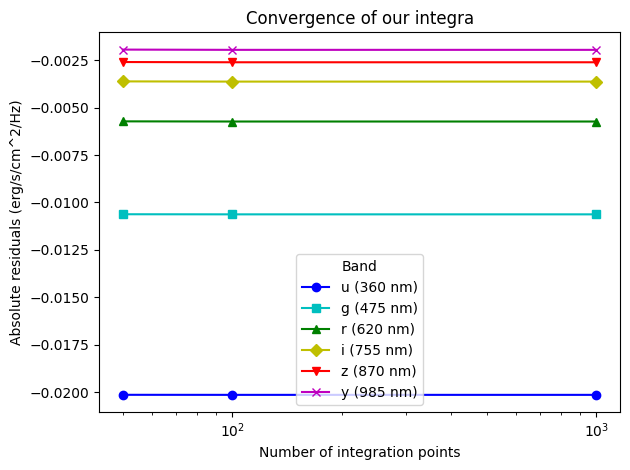

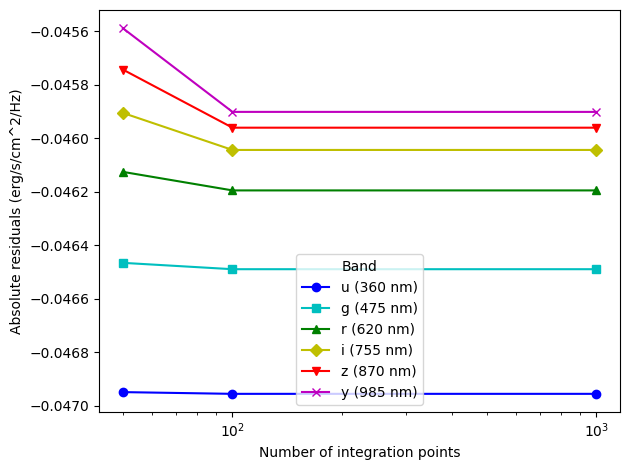

In [9]:
bandstr_to_wavelength = {'u':360, 'g':475, 'r':620, 'i':755, 'z': 870, 'y': 985}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x",}
band_colors = {"u": "#0000FF", "g":"#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}

num_integration_points = [50, 100, 1000]
fluxes = []
for num in num_integration_points:
    flux = my_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num)) / ABSOLUTE_FLUX_TO_LUM_DENSITY
    fluxes.append(flux)
fluxes = jnp.asarray(fluxes)
res = fluxes - their_fluxes
res_perc = res / their_fluxes * 100


for band, wavelength in bandstr_to_wavelength.items():
    # Find where this wavelength is in your wavelengths array
    j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

    plt.plot(
        num_integration_points,
        res[:, j],
        marker=band_markers[band],
        color=band_colors[band],
        label=f"{band} ({wavelength} nm)",
)

plt.xscale('log')
plt.title("Convergence of our integra")
plt.xlabel("Number of integration points")
plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
plt.legend(title="Band")
plt.tight_layout()
plt.show()


for band, wavelength in bandstr_to_wavelength.items():
    # Find where this wavelength is in your wavelengths array
    j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

    plt.plot(
        num_integration_points,
        res_perc[:, j],
        marker=band_markers[band],
        color=band_colors[band],
        label=f"{band} ({wavelength} nm)",
)

plt.xscale('log')
plt.xlabel("Number of integration points")
plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
plt.legend(title="Band")
plt.tight_layout()
plt.show()

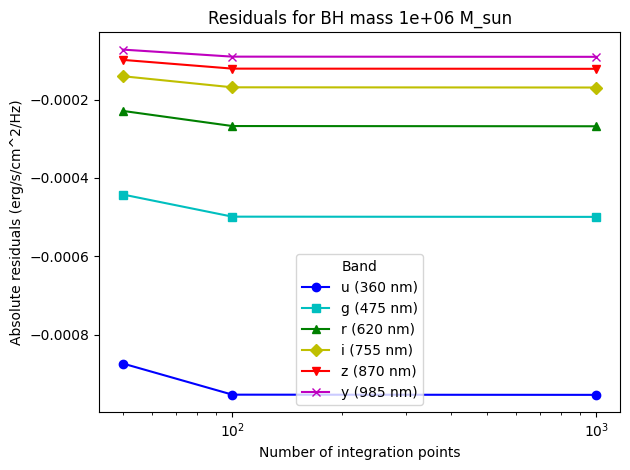

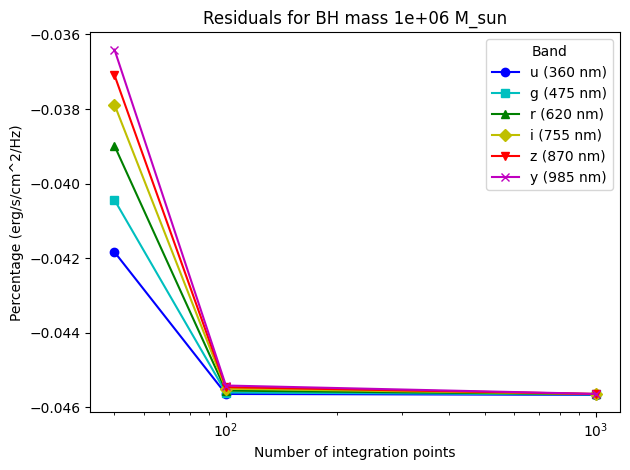

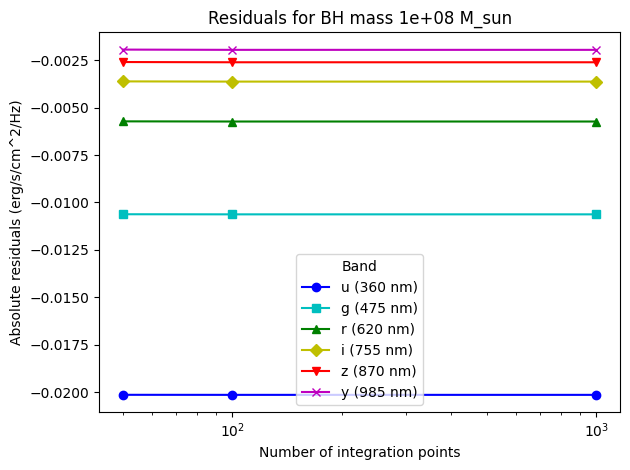

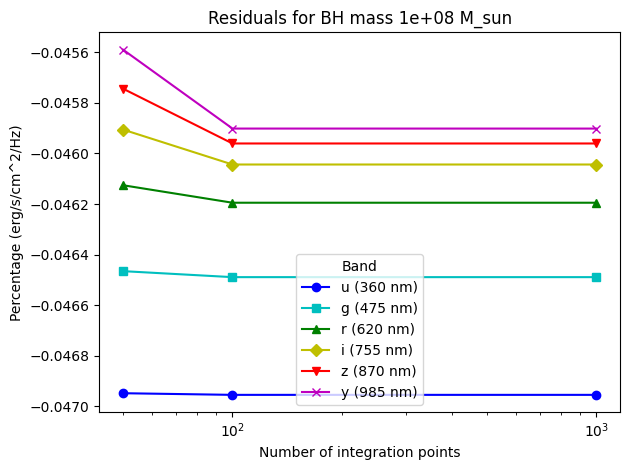

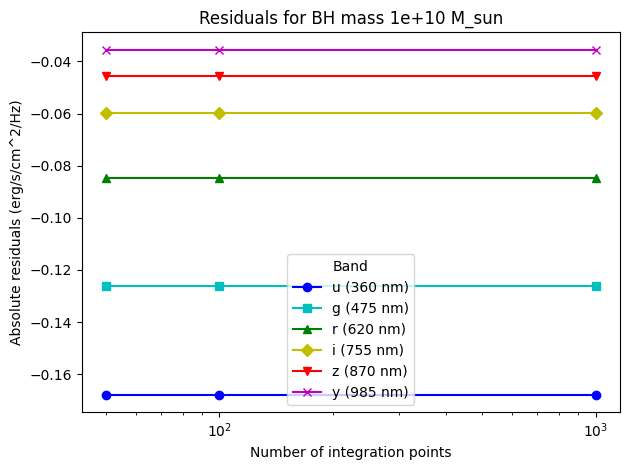

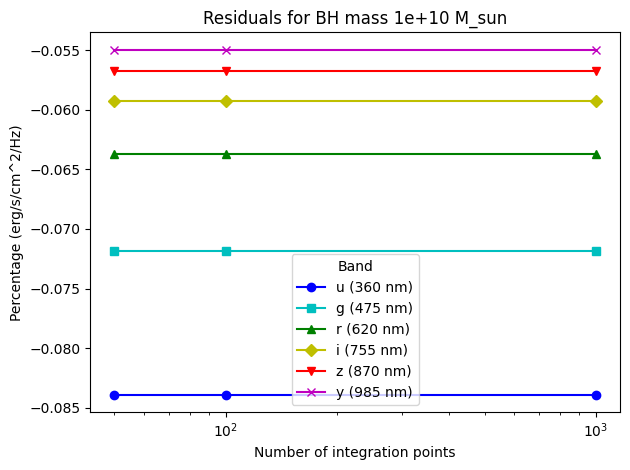

In [ ]:
bandstr_to_wavelength = {'u':360, 'g':475, 'r':620, 'i':755, 'z': 870, 'y': 985}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x",}
band_colors = {"u": "#0000FF", "g":"#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}

bh_masses = [1e6*M_sun, 1e8*M_sun, 1e10*M_sun]
acc_rates = [0.1*M_sun, 0.5*M_sun, 1.0*M_sun]

for bh_mass in bh_masses:
    my_cur_agn = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=0.5*M_sun, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
    critical_accretion_rate = 1.4e18 * (my_cur_agn.blackhole_mass.value / M_sun)
    edd_ratio = my_cur_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
    their_agn = AGN(blackhole_mass=bh_mass/M_sun, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)
    their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_cur_agn.blackhole_mass.value * 10**3), Mdot=float(my_cur_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
    their_fluxes = f_l(f_nu=their_fluxes_per_freq, nu=freqs)
    num_integration_points = [50, 100, 1000]
    fluxes = []
    for num in num_integration_points:
        flux = my_cur_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num)) / ABSOLUTE_FLUX_TO_LUM_DENSITY
        fluxes.append(flux)
    fluxes = jnp.asarray(fluxes)
    res = fluxes - their_fluxes
    res_perc = res / their_fluxes * 100


    for band, wavelength in bandstr_to_wavelength.items():
        # Find where this wavelength is in your wavelengths array
        j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

        plt.plot(
            num_integration_points,
            res[:, j],
            marker=band_markers[band],
            color=band_colors[band],
            label=f"{band} ({wavelength} nm)",
    )

    plt.xscale('log')
    plt.xlabel("Number of integration points")
    plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
    plt.title(f"Residuals for BH mass {bh_mass/M_sun:.0e} M_sun")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()


    for band, wavelength in bandstr_to_wavelength.items():
        # Find where this wavelength is in your wavelengths array
        j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

        plt.plot(
            num_integration_points,
            res_perc[:, j],
            marker=band_markers[band],
            color=band_colors[band],
            label=f"{band} ({wavelength} nm)",
    )

    plt.xscale('log')
    plt.xlabel("Number of integration points")
    plt.ylabel("Percentage (erg/s/cm^2/Hz)")
    plt.title(f"Residuals for BH mass {bh_mass/M_sun:.0e} M_sun")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()

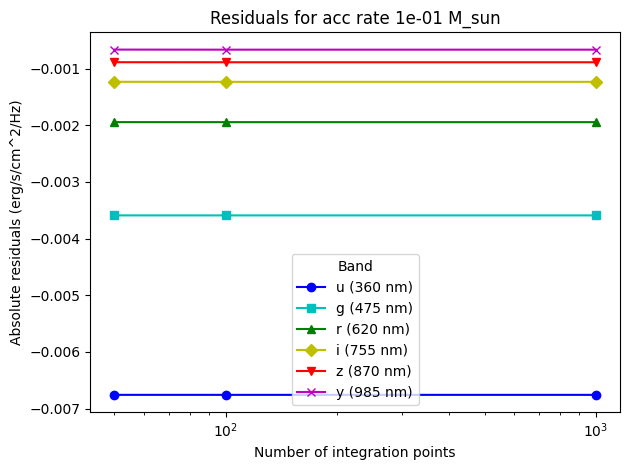

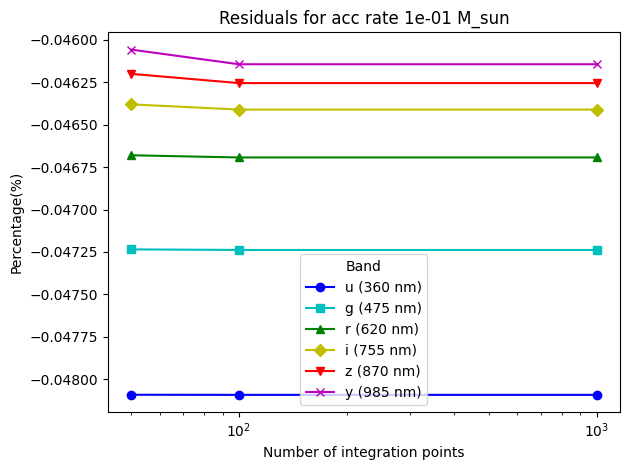

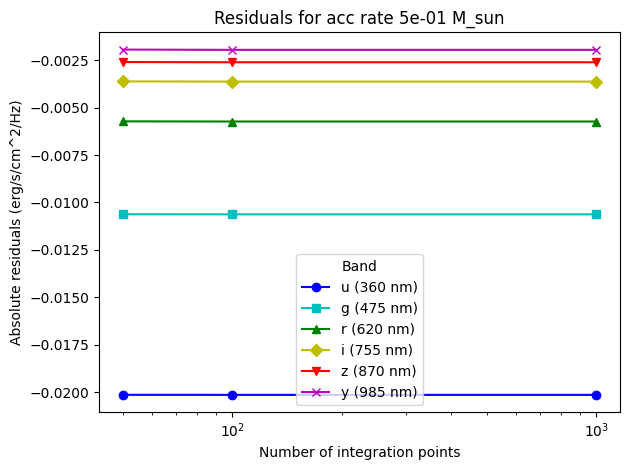

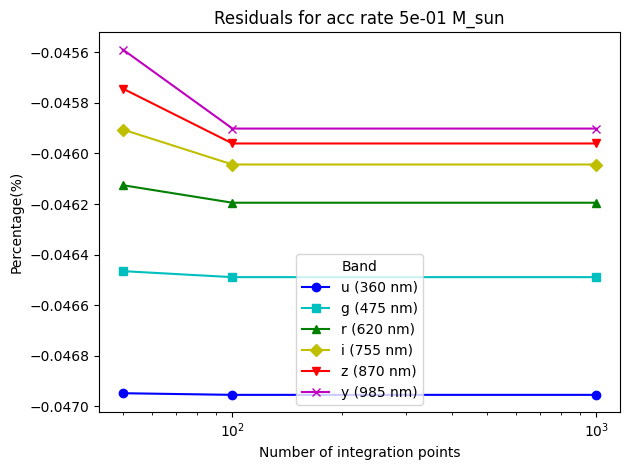

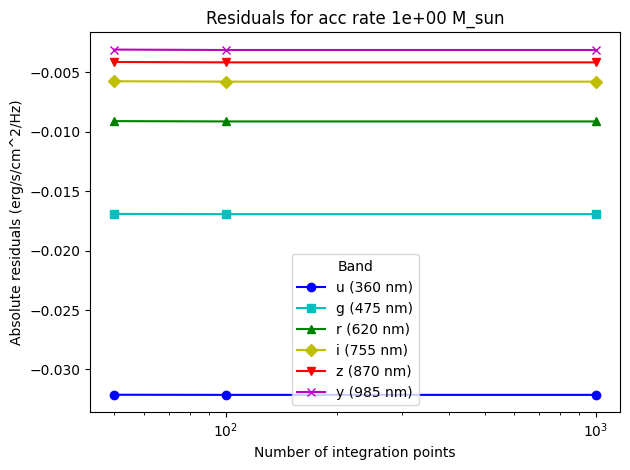

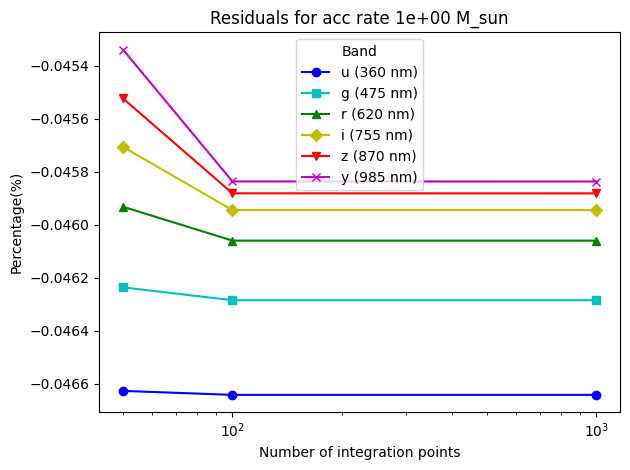

In [ ]:

for acc_rate in acc_rates:
    my_cur_agn = AGNSourceLipunova2018(blackhole_mass=M_sun*1e8, accretion_rate=acc_rate, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
    critical_accretion_rate = 1.4e18 * (my_cur_agn.blackhole_mass.value / M_sun)
    edd_ratio = my_cur_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
    their_agn = AGN(blackhole_mass=M_sun*1e8/M_sun, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)
    their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_cur_agn.blackhole_mass.value * 10**3), Mdot=float(my_cur_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
    their_fluxes = f_l(f_nu=their_fluxes_per_freq, nu=freqs)
    num_integration_points = [50, 100, 1000]
    fluxes = []
    for num in num_integration_points:
        flux = my_cur_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num)) / ABSOLUTE_FLUX_TO_LUM_DENSITY
        fluxes.append(flux)
    fluxes = jnp.asarray(fluxes)
    res = fluxes - their_fluxes
    res_perc = res / their_fluxes * 100


    for band, wavelength in bandstr_to_wavelength.items():
        # Find where this wavelength is in your wavelengths array
        j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

        plt.plot(
            num_integration_points,
            res[:, j],
            marker=band_markers[band],
            color=band_colors[band],
            label=f"{band} ({wavelength} nm)",
    )

    plt.xscale('log')
    plt.xlabel("Number of integration points")
    plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
    plt.title(f"Residuals for acc rate {acc_rate/M_sun:.0e} M_sun")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()


    for band, wavelength in bandstr_to_wavelength.items():
        # Find where this wavelength is in your wavelengths array
        j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

        plt.plot(
            num_integration_points,
            res_perc[:, j],
            marker=band_markers[band],
            color=band_colors[band],
            label=f"{band} ({wavelength} nm)",
    )

    plt.xscale('log')
    plt.xlabel("Number of integration points")
    plt.ylabel("Percentage(%)")
    plt.title(f"Residuals for acc rate {acc_rate/M_sun:.0e} M_sun")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()

In [ ]:
dist_parsecs = [10, 1e3, 1e5, 1e9]
dis_cm = [d * 3.086e18 for d in dist_parsecs]


for i  in range(len(dist_parsecs)):
    my_cur_agn = AGNSourceLipunova2018(blackhole_mass=M_sun*1e8, accretion_rate=0.5*M_sun, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
    critical_accretion_rate = 1.4e18 * (my_cur_agn.blackhole_mass.value / M_sun)
    edd_ratio = my_cur_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
    their_agn = AGN(blackhole_mass=M_sun*1e8/M_sun, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=dist_parsecs[i])
    their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_cur_agn.blackhole_mass.value * 10**3), Mdot=float(my_cur_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=dis_cm[i])/1e32
    their_fluxes = f_l(f_nu=their_fluxes_per_freq, nu=freqs)
    num_integration_points = [50, 100, 1000, 1e5, 1e7]
    fluxes = []
    for num in num_integration_points:
        flux = my_cur_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num)) / ABSOLUTE_FLUX_TO_LUM_DENSITY
        fluxes.append(flux)
    fluxes = jnp.asarray(fluxes)
    res = fluxes - their_fluxes
    res_perc = res / their_fluxes * 100


    for band, wavelength in bandstr_to_wavelength.items():
        # Find where this wavelength is in your wavelengths array
        j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

        plt.plot(
            num_integration_points,
            res[:, j],
            marker=band_markers[band],
            color=band_colors[band],
            label=f"{band} ({wavelength} nm)",
    )

    plt.xscale('log')
    plt.xlabel("Number of integration points")
    plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
    plt.title(f"Residuals for distance {dist_parsecs[i]} parsec")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()


    for band, wavelength in bandstr_to_wavelength.items():
        # Find where this wavelength is in your wavelengths array
        j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

        plt.plot(
            num_integration_points,
            res_perc[:, j],
            marker=band_markers[band],
            color=band_colors[band],
            label=f"{band} ({wavelength} nm)",
    )

    plt.xscale('log')
    plt.xlabel("Number of integration points")
    plt.ylabel("Percentage(%)")
    plt.title(f"Residuals for distance {dist_parsecs[i]} parsec")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()

TypeError: AGNSourceLipunova2018.base_luminosity_density() got an unexpected keyword argument 'd'

# Comparing different integration methods

In [ ]:
lims = [10, 50, 100, 1000]
bandstr_to_wavelength = {'u':360, 'g':475, 'r':620, 'i':755, 'z': 870, 'y': 985}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x",}
band_colors = {"u": "#0000FF", "g":"#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}

bh_masses = [1e6*M_sun, 1e8*M_sun, 1e10*M_sun]
acc_rates = [0.1*M_sun, 0.5*M_sun, 1.0*M_sun]
num_int_points = [50, 100, 1000]

for lim in lims:
    for bh_mass in bh_masses:
        my_cur_agn = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=0.5*M_sun, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
        critical_accretion_rate = 1.4e18 * (my_cur_agn.blackhole_mass.value / M_sun)
        edd_ratio = my_cur_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
        their_agn = AGN(blackhole_mass=bh_mass/M_sun, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)
        their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_cur_agn.blackhole_mass.value * 10**3), Mdot=float(my_cur_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
        their_fluxes = f_l(f_nu=their_fluxes_per_freq, nu=freqs)
        num_integration_points = [50, 100, 1000]
        fluxes = []
        for num in num_integration_points:
            flux = my_cur_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num), lim=lim) / ABSOLUTE_FLUX_TO_LUM_DENSITY
            fluxes.append(flux)
        fluxes = jnp.asarray(fluxes)
        res = fluxes - their_fluxes
        res_perc = res / their_fluxes * 100


        for band, wavelength in bandstr_to_wavelength.items():
            # Find where this wavelength is in your wavelengths array
            j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

            plt.plot(
                num_integration_points,
                res[:, j],
                marker=band_markers[band],
                color=band_colors[band],
                label=f"{band} ({wavelength} nm)",
        )

        plt.xscale('log')
        plt.xlabel("Number of integration points")
        plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
        plt.title(f"Residuals for BH mass {bh_mass/M_sun:.0e} M_sun")
        plt.legend(title="Band")
        plt.tight_layout()
        plt.show()


        for band, wavelength in bandstr_to_wavelength.items():
            # Find where this wavelength is in your wavelengths array
            j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

            plt.plot(
                num_integration_points,
                res_perc[:, j],
                marker=band_markers[band],
                color=band_colors[band],
                label=f"{band} ({wavelength} nm)",
        )

        plt.xscale('log')
        plt.xlabel("Number of integration points")
        plt.ylabel("Percentage (erg/s/cm^2/Hz)")
        plt.title(f"Residuals for BH mass {bh_mass/M_sun:.0e} M_sun")
        plt.legend(title="Band")
        plt.tight_layout()
        plt.show()

    for acc_rate in acc_rates:
        my_cur_agn = AGNSourceLipunova2018(blackhole_mass=M_sun*1e8, accretion_rate=acc_rate, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
        critical_accretion_rate = 1.4e18 * (my_cur_agn.blackhole_mass.value / M_sun)
        edd_ratio = my_cur_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
        their_agn = AGN(blackhole_mass=M_sun*1e8/M_sun, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)
        their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_cur_agn.blackhole_mass.value * 10**3), Mdot=float(my_cur_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
        their_fluxes = f_l(f_nu=their_fluxes_per_freq, nu=freqs)
        num_integration_points = [50, 100, 1000]
        fluxes = []
        for num in num_integration_points:
            flux = my_cur_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num), lim=lim) / ABSOLUTE_FLUX_TO_LUM_DENSITY
            fluxes.append(flux)
        fluxes = jnp.asarray(fluxes)
        res = fluxes - their_fluxes
        res_perc = res / their_fluxes * 100


        for band, wavelength in bandstr_to_wavelength.items():
            # Find where this wavelength is in your wavelengths array
            j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

            plt.plot(
                num_integration_points,
                res[:, j],
                marker=band_markers[band],
                color=band_colors[band],
                label=f"{band} ({wavelength} nm)",
        )

        plt.xscale('log')
        plt.xlabel("Number of integration points")
        plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
        plt.title(f"Residuals for acc rate {acc_rate/M_sun:.0e} M_sun")
        plt.legend(title="Band")
        plt.tight_layout()
        plt.show()


        for band, wavelength in bandstr_to_wavelength.items():
            # Find where this wavelength is in your wavelengths array
            j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

            plt.plot(
                num_integration_points,
                res_perc[:, j],
                marker=band_markers[band],
                color=band_colors[band],
                label=f"{band} ({wavelength} nm)",
        )

        plt.xscale('log')
        plt.xlabel("Number of integration points")
        plt.ylabel("Percentage(%)")
        plt.title(f"Residuals for acc rate {acc_rate/M_sun:.0e} M_sun")
        plt.legend(title="Band")
        plt.tight_layout()
        plt.show()
    
    for num in num_int_points:
        my_cur_agn = AGNSourceLipunova2018(blackhole_mass=M_sun*1e8, accretion_rate=acc_rate, inclination_angle=0.0, perturbations_ar=perturbations, start_time=6300, end_time=6600)
        critical_accretion_rate = 1.4e18 * (my_cur_agn.blackhole_mass.value / M_sun)
        edd_ratio = my_cur_agn.accretion_rate.value * 1e3 / SECS_IN_YEAR/ critical_accretion_rate
        their_agn = AGN(blackhole_mass=M_sun*1e8/M_sun, edd_ratio=edd_ratio, inclination_angle=0.0, t0=6300, redshift=0.000000002369, distance=10)
        their_fluxes_per_freq = their_agn.compute_sed_standard_disk(nu=freqs, rin_to_rg=6, M= float(my_cur_agn.blackhole_mass.value * 10**3), Mdot=float(my_cur_agn.accretion_rate.value * 10**3 / SECS_IN_YEAR), i=0, d=10* 3.086e18)/1e32
        their_fluxes = f_l(f_nu=their_fluxes_per_freq, nu=freqs)
        num_integration_points = [50, 100, 1000]
        fluxes = []
        for num in num_integration_points:
            flux = my_cur_agn.base_luminosity_density(w=wavelengths, num_integration_points=int(num)) / ABSOLUTE_FLUX_TO_LUM_DENSITY
            fluxes.append(flux)
        fluxes = jnp.asarray(fluxes)
        res = fluxes - their_fluxes
        res_perc = res / their_fluxes * 100


        for band, wavelength in bandstr_to_wavelength.items():
            # Find where this wavelength is in your wavelengths array
            j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

            plt.plot(
                num_integration_points,
                res[:, j],
                marker=band_markers[band],
                color=band_colors[band],
                label=f"{band} ({wavelength} nm)",
        )

        plt.xscale('log')
        plt.xlabel("Number of integration points")
        plt.ylabel("Absolute residuals (erg/s/cm^2/Hz)")
        plt.title(f"Residuals for acc rate {acc_rate/M_sun:.0e} M_sun")
        plt.legend(title="Band")
        plt.tight_layout()
        plt.show()


        for band, wavelength in bandstr_to_wavelength.items():
            # Find where this wavelength is in your wavelengths array
            j = np.where(np.asarray(wavelengths) == wavelength)[0][0]

            plt.plot(
                num_integration_points,
                res_perc[:, j],
                marker=band_markers[band],
                color=band_colors[band],
                label=f"{band} ({wavelength} nm)",
        )

        plt.xscale('log')
        plt.xlabel("Number of integration points")
        plt.ylabel("Percentage(%)")
        plt.title(f"Residuals for acc rate {acc_rate/M_sun:.0e} M_sun")
        plt.legend(title="Band")
        plt.tight_layout()
        plt.show()

TypeError: AGNSourceLipunova2018.base_luminosity_density() got an unexpected keyword argument 'lim'